# Nuclear Heat Exchanger Data Analysis
**Course:** SWEP 200, Assignment II

This notebook explores a dataset of 1,000 operating records from a nuclear plant heat exchanger. It has four parts:

1. Load and inspect the data
2. Explore distributions and relationships (EDA)
3. Engineer a physically meaningful feature (LMTD)
4. Build simple machine learning models to predict **Plant Power (%)**

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_theme(style="whitegrid")

## 2. Load the Data

In [2]:
df = pd.read_csv("nuclear_heat_exchanger_1000_data.csv")
print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (1000, 8)


,Hot_Inlet_Temp_C,Hot_Outlet_Temp_C,Cold_Inlet_Temp_C,Cold_Outlet_Temp_C,Hot_Mass_Flow_kg_s,Cold_Mass_Flow_kg_s,Overall_U_W_m2K,Plant_Power_Percent
0,310.6,291.0,213.7,266.5,15474.5,415.6,5689.0,58.4
1,309.2,290.3,212.1,266.5,15379.3,390.7,5582.0,55.2
2,319.2,291.6,219.9,272.5,15497.2,587.6,5583.0,81.8
3,320.8,292.4,221.8,274.3,15628.5,621.5,5671.0,85.3
4,308.9,291.6,211.1,264.0,15364.9,359.1,5631.0,51.6


## 3. Data Inspection

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Hot_Inlet_Temp_C     1000 non-null   float64
 1   Hot_Outlet_Temp_C    1000 non-null   float64
 2   Cold_Inlet_Temp_C    1000 non-null   float64
 3   Cold_Outlet_Temp_C   1000 non-null   float64
 4   Hot_Mass_Flow_kg_s   1000 non-null   float64
 5   Cold_Mass_Flow_kg_s  1000 non-null   float64
 6   Overall_U_W_m2K      1000 non-null   float64
 7   Plant_Power_Percent  1000 non-null   float64
dtypes: float64(8)
memory usage: 62.6 KB


In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Hot_Inlet_Temp_C,1000.0,317.06,5.23,307.4,312.40,317.2,321.50,326.9
Hot_Outlet_Temp_C,1000.0,291.63,0.68,289.7,291.20,291.6,292.10,293.9
Cold_Inlet_Temp_C,1000.0,218.67,4.55,210.0,214.60,218.9,222.50,226.8
Cold_Outlet_Temp_C,1000.0,271.34,4.13,263.4,267.70,271.4,274.92,279.3
Hot_Mass_Flow_kg_s,1000.0,15402.90,146.88,14913.8,15302.85,15403.8,15497.22,15977.9
Cold_Mass_Flow_kg_s,1000.0,537.72,103.65,353.5,446.32,541.5,625.12,734.1
Overall_U_W_m2K,1000.0,5039.69,349.71,4375.0,4743.75,5044.0,5349.50,5705.0
Plant_Power_Percent,1000.0,75.18,14.42,50.2,62.40,75.8,87.32,100.0


In [5]:
print("Missing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
Hot_Inlet_Temp_C       0
Hot_Outlet_Temp_C      0
Cold_Inlet_Temp_C      0
Cold_Outlet_Temp_C     0
Hot_Mass_Flow_kg_s     0
Cold_Mass_Flow_kg_s    0
Overall_U_W_m2K        0
Plant_Power_Percent    0
dtype: int64

Duplicate rows: 0


The dataset has no missing values and no duplicate rows, so no cleaning is needed. All 8 columns are numeric.

## 4. Exploratory Data Analysis

### 4.1 Distribution of each variable

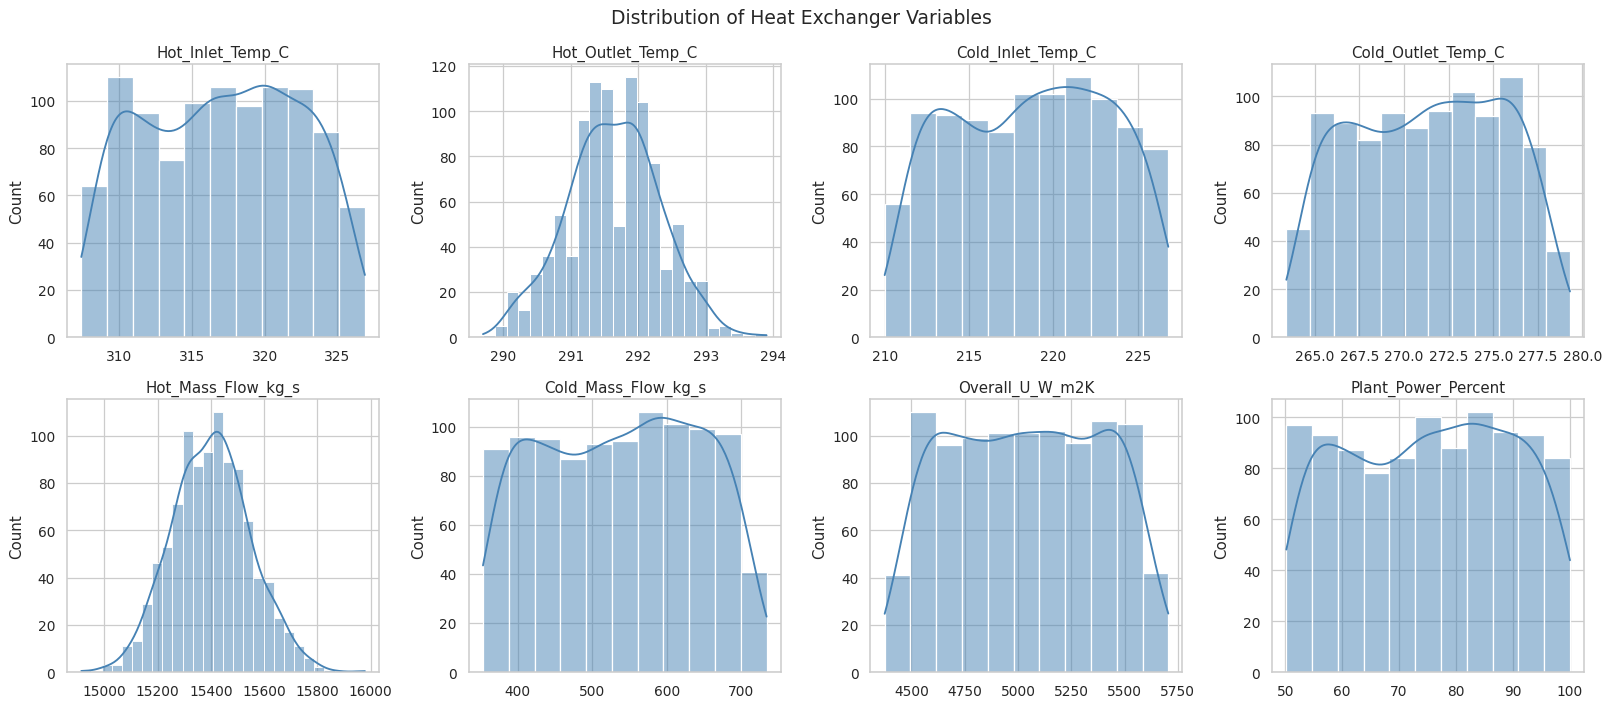

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), df.columns):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Distribution of Heat Exchanger Variables", fontsize=15)
plt.tight_layout()
plt.show()

### 4.2 Correlation between variables

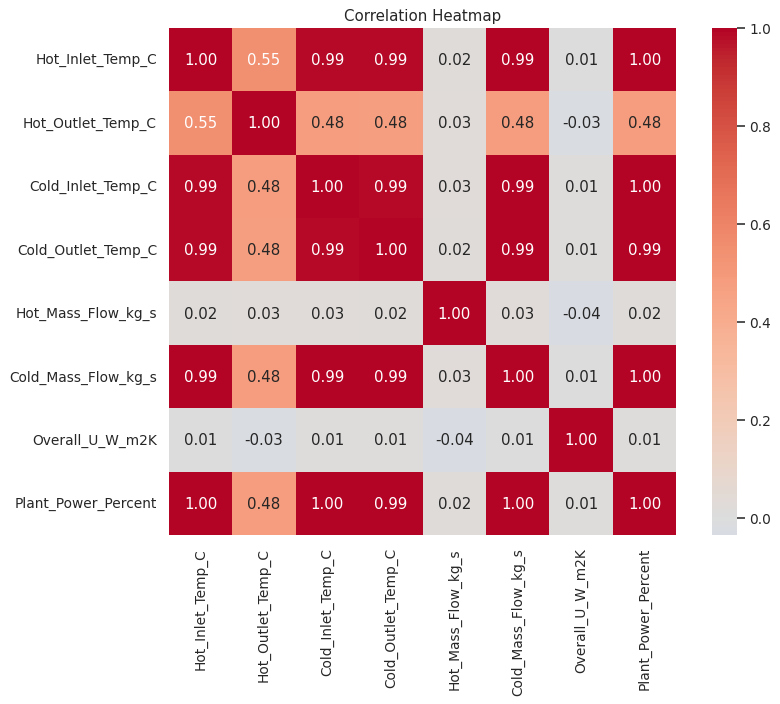

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

**Observations**
- Hot inlet temperature, cold inlet temperature, cold outlet temperature, cold mass flow and plant power are all almost perfectly correlated (about 0.99 to 1.00). They rise and fall together with plant load.
- Hot outlet temperature is only moderately correlated with these (about 0.5), so the hot side holds its outlet temperature fairly steady.
- Hot mass flow and the overall heat transfer coefficient (U) are essentially uncorrelated with plant power. They stay roughly constant regardless of load.
- Because so many features move together, they carry overlapping information (multicollinearity).

### 4.3 How the variables change with plant power

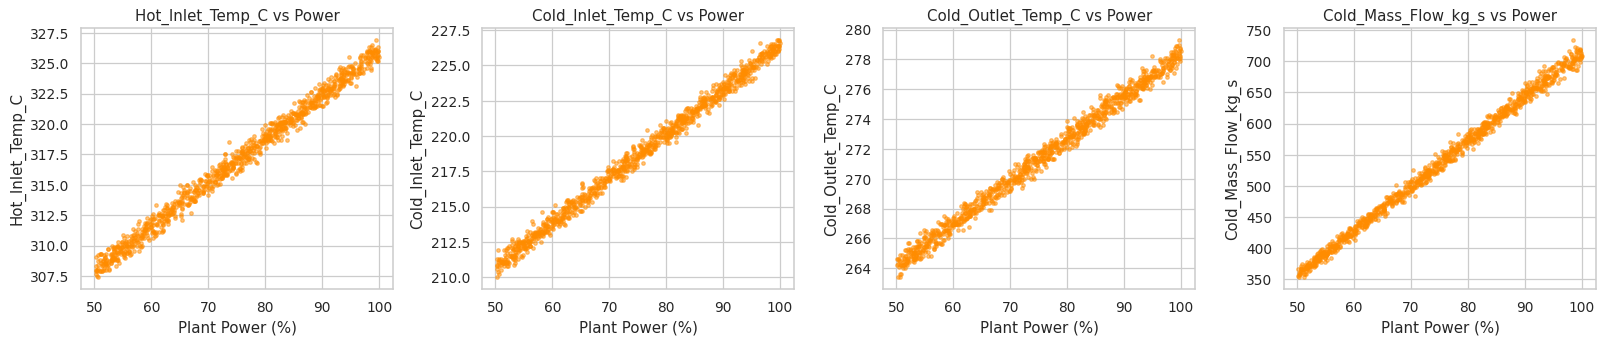

In [8]:
features = ["Hot_Inlet_Temp_C", "Cold_Inlet_Temp_C", "Cold_Outlet_Temp_C", "Cold_Mass_Flow_kg_s"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, features):
    ax.scatter(df["Plant_Power_Percent"], df[col], s=8, alpha=0.5, color="darkorange")
    ax.set_xlabel("Plant Power (%)")
    ax.set_ylabel(col)
    ax.set_title(f"{col} vs Power")
plt.tight_layout()
plt.show()

These variables all show a clear, roughly linear rise with plant power, which supports a linear model later.

### 4.4 Variables that do not depend on power

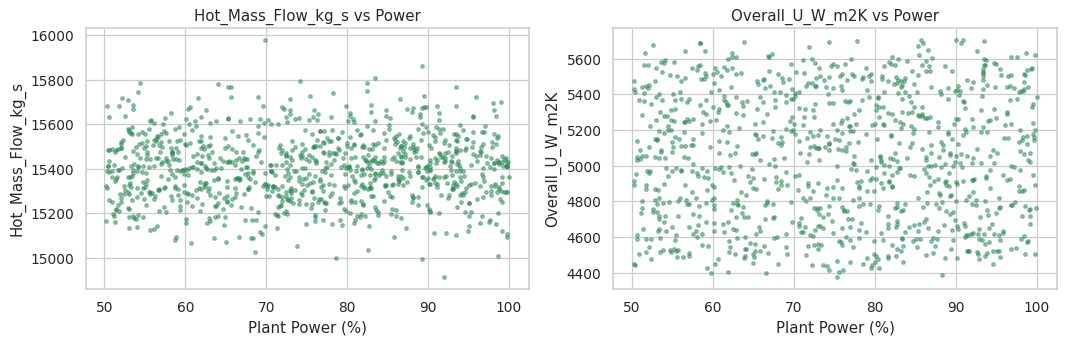

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["Hot_Mass_Flow_kg_s", "Overall_U_W_m2K"]):
    ax.scatter(df["Plant_Power_Percent"], df[col], s=8, alpha=0.5, color="seagreen")
    ax.set_xlabel("Plant Power (%)")
    ax.set_ylabel(col)
    ax.set_title(f"{col} vs Power")
plt.tight_layout()
plt.show()

Hot mass flow and U show no trend with power. They scatter around a constant level, so they are unlikely to help predict power.

## 5. Feature Engineering: Log Mean Temperature Difference (LMTD)

LMTD is the standard driving-force measure for heat transfer in a heat exchanger. For a counter-flow arrangement:

$$\Delta T_1 = T_{h,in} - T_{c,out}, \qquad \Delta T_2 = T_{h,out} - T_{c,in}$$

$$LMTD = \frac{\Delta T_1 - \Delta T_2}{\ln(\Delta T_1 / \Delta T_2)}$$

Counter-flow is assumed here because the dataset does not state the flow arrangement.

In [10]:
dT1 = df["Hot_Inlet_Temp_C"] - df["Cold_Outlet_Temp_C"]
dT2 = df["Hot_Outlet_Temp_C"] - df["Cold_Inlet_Temp_C"]

# Use dT1 where the two differences are equal, to avoid dividing by zero
same = np.isclose(dT1, dT2)
lmtd = np.where(same, dT1, (dT1 - dT2) / np.log(dT1 / dT2))

df["LMTD_C"] = lmtd
print("Minimum dT1, dT2:", dT1.min().round(2), dT2.min().round(2), "(both positive, so the log is valid)")
df["LMTD_C"].describe().round(2)

Minimum dT1, dT2: 42.5 64.9 (both positive, so the log is valid)


,LMTD_C
count,1000.00
mean,58.25
std,1.32
min,55.10
25%,57.24
50%,58.20
75%,59.28
max,62.13


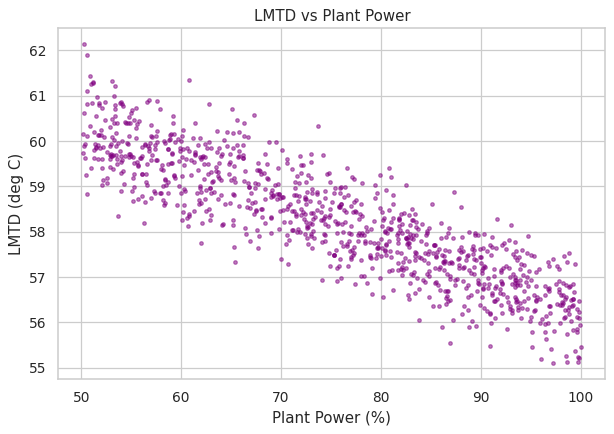

In [11]:
plt.figure(figsize=(7, 5))
plt.scatter(df["Plant_Power_Percent"], df["LMTD_C"], s=8, alpha=0.5, color="purple")
plt.xlabel("Plant Power (%)")
plt.ylabel("LMTD (deg C)")
plt.title("LMTD vs Plant Power")
plt.tight_layout()
plt.show()

## 6. Machine Learning: Predicting Plant Power (%)

**Goal:** predict `Plant_Power_Percent` from the measured heat exchanger variables.

**Approach:**
- Split the data 80% train and 20% test
- Train a **Linear Regression** (simple baseline) and a **Random Forest** (non-linear model)
- Compare them on the unseen test set

In [12]:
X = df.drop(columns=["Plant_Power_Percent", "LMTD_C"])   # original measured variables only
y = df["Plant_Power_Percent"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training rows:", X_train.shape[0], "| Test rows:", X_test.shape[0])

Training rows: 800 | Test rows: 200


In [13]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
}

results = []
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions[name] = pred
    results.append({
        "Model": name,
        "R2": r2_score(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAE": mean_absolute_error(y_test, pred),
    })

pd.DataFrame(results).round(4)

,Model,R2,RMSE,MAE
0,Linear Regression,0.9987,0.5231,0.4216
1,Random Forest,0.9977,0.6837,0.5482


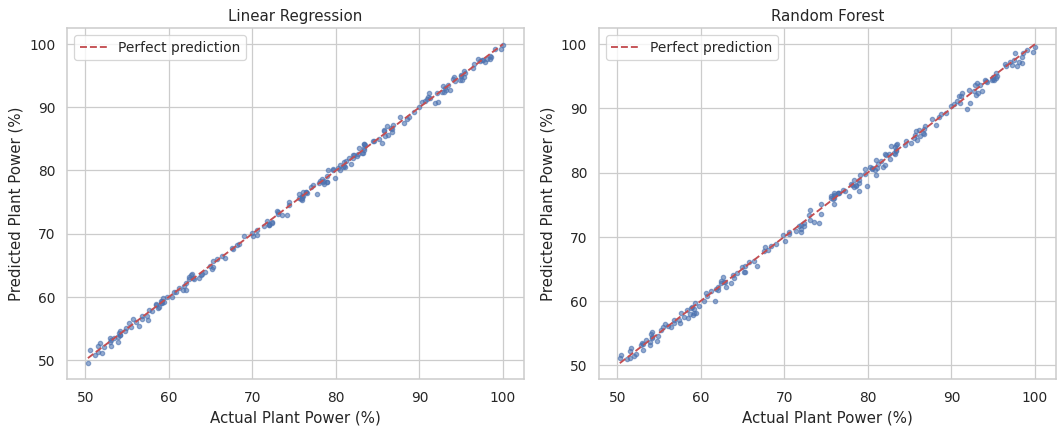

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, pred) in zip(axes, predictions.items()):
    ax.scatter(y_test, pred, s=12, alpha=0.6)
    lims = [y_test.min(), y_test.max()]
    ax.plot(lims, lims, "r--", label="Perfect prediction")
    ax.set_xlabel("Actual Plant Power (%)")
    ax.set_ylabel("Predicted Plant Power (%)")
    ax.set_title(name)
    ax.legend()
plt.tight_layout()
plt.show()

### 6.1 Which variables matter most?

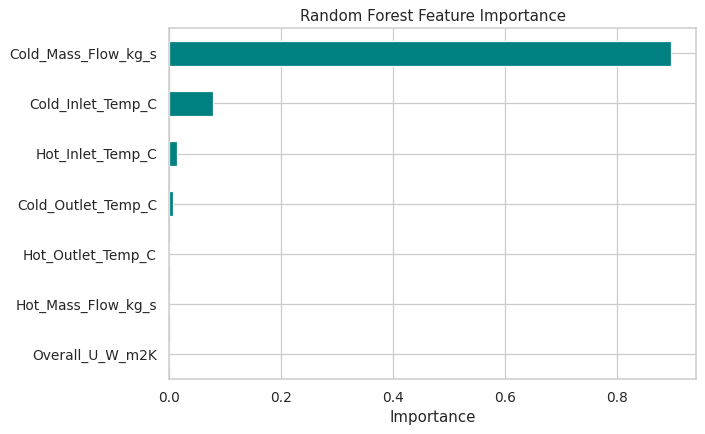

In [15]:
rf = models["Random Forest"]
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8, 5))
importance.plot(kind="barh", color="teal")
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

## 7. Conclusions

- **Data quality:** the dataset is clean, with 1,000 rows, 8 numeric columns, and no missing or duplicate values.
- **Key relationship:** plant power is almost perfectly linear with the hot inlet temperature, cold inlet temperature, cold outlet temperature, and cold mass flow. The heat exchanger's temperatures and cooling flow scale with load.
- **Variables unrelated to load:** hot mass flow and the overall heat transfer coefficient (U) do not change with power.
- **Modelling:** both models predict plant power very accurately on unseen data (R2 above 0.99). The simple Linear Regression does slightly better than the Random Forest, which fits because the underlying relationships are close to linear.
- **Caveat:** the input variables are highly correlated with each other, so individual feature importances and coefficients should be read with care. The accuracy of the predictions is reliable, but the split of credit between correlated features is not.
- **Possible next steps:** try regularised regression (Ridge or Lasso) to handle multicollinearity, or predict U from the other variables to look for fouling effects.